In [1]:
# Add module to path
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from itertools import product
from numba import jit, njit, types
from numba.typed import Dict
import time

from darts.dartboards import generate_dartboard
from darts.stats import expected_score, std_score, gaussian_filter

In [3]:
board_size = 128

In [4]:
board, checkouts = generate_dartboard(board_size)

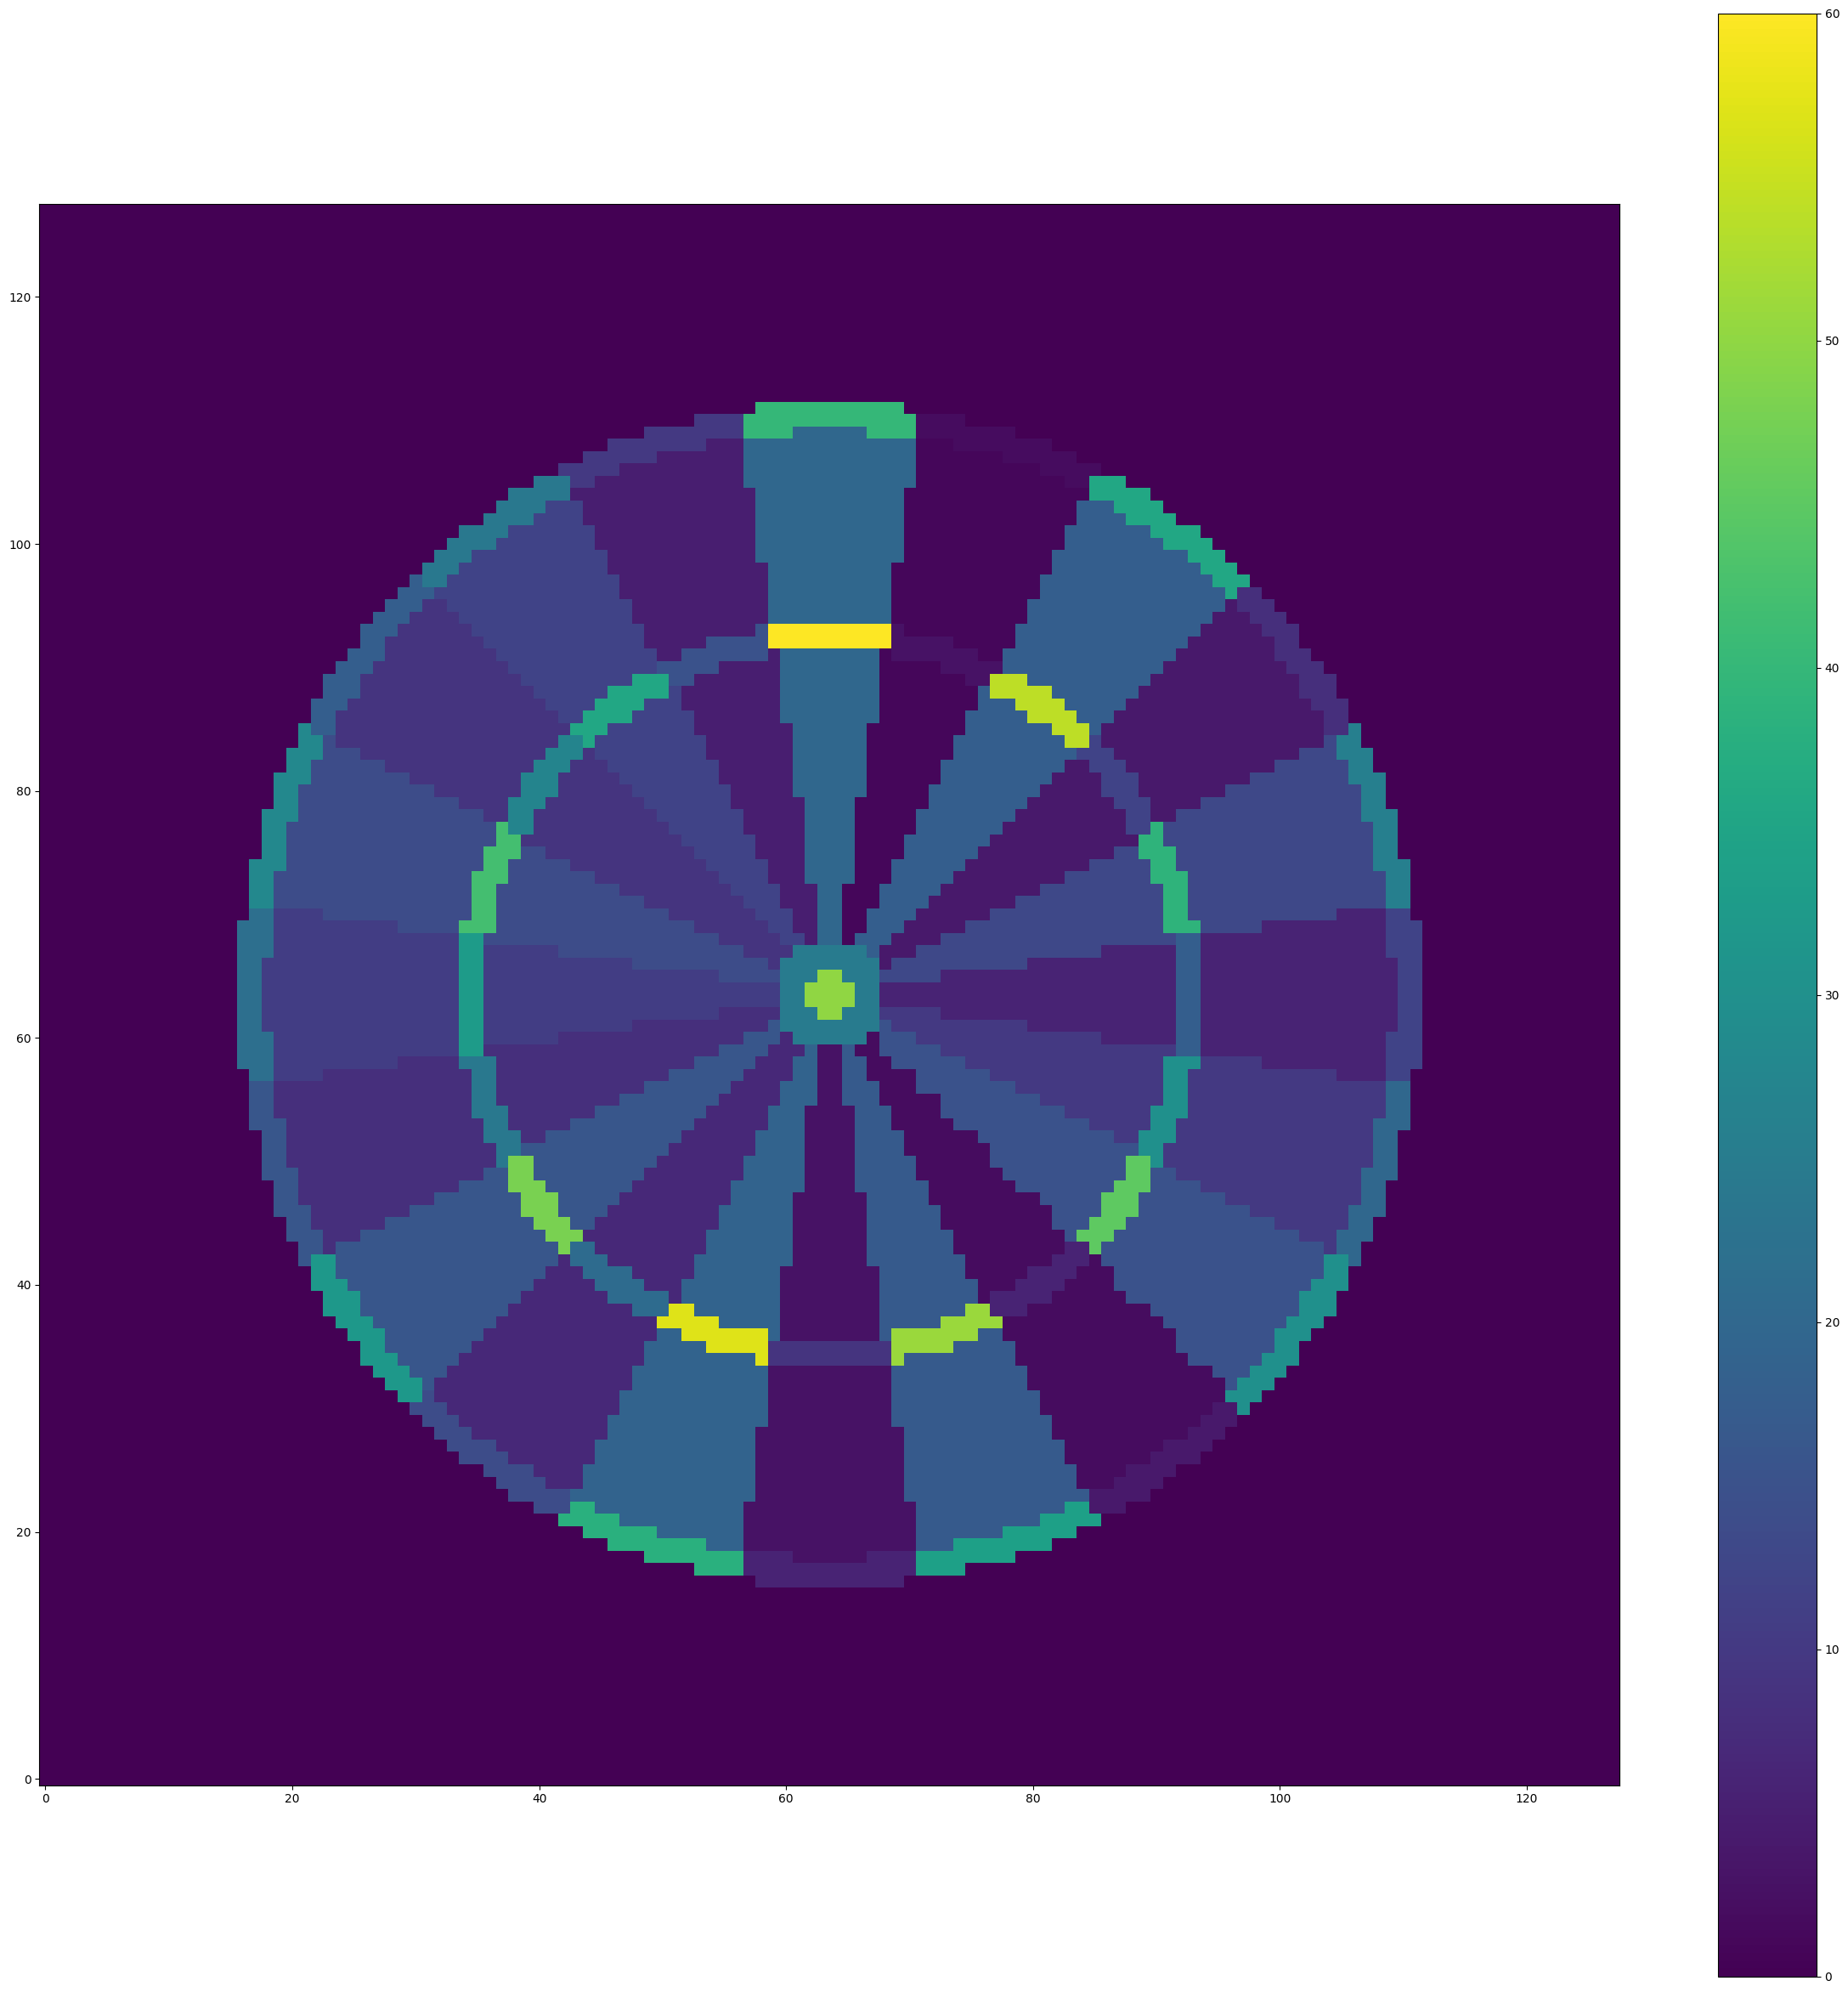

In [5]:
fig, ax = plt.subplots(figsize=(30, 30))
plt.imshow(board, origin='lower')
plt.colorbar()

In [6]:
sigma = 8

In [7]:
mu = np.array([0, 0])
Sigma = sigma*sigma*np.array([[1, 0], [0, 1]])

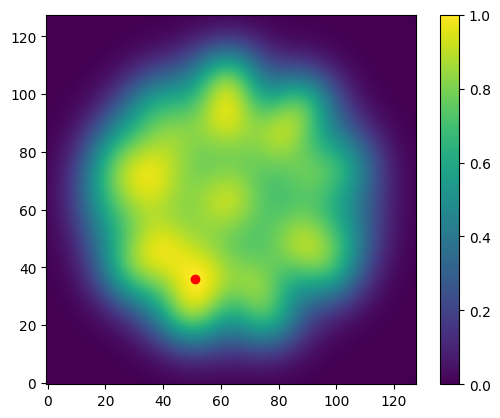

In [8]:
exp = expected_score(board, mu, Sigma, padding=100)
i, j = np.unravel_index(np.argmax(exp), board.shape)
plt.imshow(exp, origin='lower')
plt.scatter(j, i, color='red')
plt.colorbar()

#### States

State $S$ is defined by:
- Current score $s$
- Current throw $t$
- Starting score $u$

Remove some points that are too far from the dartboard

In [9]:
radius_pixels = int(170/225.5*board_size/2)
margin = 2*sigma

In [10]:
centre = np.array([int(board_size/2), int(board_size/2)])
ratio = 1 # board_size//200
points = [(ratio*i, ratio*j) for i, j in product(range(board_size//ratio), range(board_size//ratio))
          if np.linalg.norm(np.array([ratio*i, ratio*j]) - centre) < radius_pixels + margin]

In [11]:
len(points)

12849

In [12]:
len(points)/board_size**2

0.78424072265625

Let's start by initializing values to 0:

In [13]:
game_start = 501

In [14]:
nonzero_values = {(0, turn, start): 1 for turn, start in product([0, 1, 2], range(game_start+1))}
zero_values = {
    (score, turn, start): 0 for score, turn, start in product(range(1, game_start+1), [0, 1, 2], range(1, game_start+1))
}

In [15]:
values = {**zero_values, **nonzero_values}

In [16]:
## Simplified
values = {score: 0 for score in range(game_start+1)}

In [17]:
len(values)

502

In [18]:
len(points)

12849

### Transition probabilities

Compute transition probabilities
Probability defined by:
- initial state
- final state
- point aimed at

In [19]:
%load_ext line_profiler

In [20]:
np.unique(board)

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 24., 25., 26.,
       27., 28., 30., 32., 33., 34., 36., 38., 39., 40., 42., 45., 48.,
       50., 51., 54., 57., 60.])

In [21]:
allowed_scores = np.array([0, 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 30, 32, 33, 34,
        36, 38, 39, 40, 42, 45, 48, 50, 51, 54, 57, 60])

In [23]:
@njit
def prob_score(filt, board, allowed_scores, checkouts):
    probs = {np.int32(s): 0.0 for s in allowed_scores}
    checkout_probs = {int(s): 0.0 for s in allowed_scores}
    for i in range(filt.shape[0]):
        for j in range(filt.shape[1]):
            probs[int(board[i, j])] += filt[i, j]
            
            if checkouts[i, j]:
                checkout_probs[int(board[i, j])] += filt[i, j]
                
    return probs, checkout_probs

In [24]:
def transition_probs(start, board, allowed_scores, checkouts, Sigma):
    gf = gaussian_filter(board, start, Sigma)
    gf = gf / np.sum(gf)
    return prob_score(gf, board, allowed_scores, checkouts)

In [25]:
probs = {}
checkout_probs = {}
for start in tqdm(points):
    probs[start], checkout_probs[start] = transition_probs(start - centre, 
                                                           board, 
                                                           allowed_scores,
                                                           checkouts,
                                                           Sigma)

  0%|                                                                                        | 0/12849 [00:00<?, ?it/s]C:\Users\mikey\AppData\Local\Temp\ipykernel_35032\3580413518.py:7: NumbaTypeSafetyWarning: unsafe cast from int64 to int32. Precision may be lost.
  probs[int(board[i, j])] += filt[i, j]
100%|███████████████████████████████████████████████████████████████████████████| 12849/12849 [00:19<00:00, 671.31it/s]


128: 19seconds

256: 4min 42seconds

360: 14min 48seconds

In [26]:
import json

# probs_file = f'transition_probs/{board_size}-pixel_{sigma}-sigma-{margin}-margin'
# with open(probs_file, 'w') as f: 
#     json.dump({','.join([str(i) for i in k]): dict(v) for k, v in probs.items()}, f)

In [27]:
# probs_file = f'transition_probs/checkout_{board_size}-pixel_{sigma}-sigma-{margin}-margin'
# with open(probs_file, 'w') as f: 
#     json.dump({','.join([str(i) for i in k]): dict(v) for k, v in checkout_probs.items()}, f)

In [28]:
probs[(64, 64)][50]

0.029876338479949416

In [29]:
checkout_probs[(64, 64)][50]

0.029876338479949416

In [30]:
@njit
def _compute_state_value(state, values, points, probs, checkout_probs, threshold):
    if state == 0 or state == 1:
        values[state] = 0
        return values
    
    delta = np.inf
    while delta > threshold:
        max_q = -np.inf
        max_a = None

        for point in points:
            key = f'{point[0]},{point[1]}'
            p = probs[key]
            cp = checkout_probs[key]
            q = 0
            
            for score in p:
                
                # Valid throw
                if score <= state-2:
                    q += p[score]*(values[state-score] - 1)

                # Checkout
                elif score == state:
                    q += cp[score]*(values[0] - 1)
                    q += (p[score] - cp[score])*(values[state] - 1)

                # Bust
                else:
                    q += p[score]*(values[state] - 1) 

            if q >= max_q:
                max_q = q
                max_a = point
                
        delta = np.abs(max_q - values[state])
        values[state] = max_q
        
    return values

@njit
def _compute_actions(values, points, probs, checkout_probs):
    
    policy = Dict.empty(key_type=types.int32, value_type=types.int32[:])
    
    for state in values:
        if state == 0 or state == 1:
            policy[state] = points[0]
            
        max_q = -np.inf
        max_a = None

        for point in points:
            key = f'{point[0]},{point[1]}'
            p = probs[key]
            cp = checkout_probs[key]
            q = 0
            
            for score in p:
                
                # Valid throw
                if score <= state-2:
                    q += p[score]*(values[state-score] - 1)

                # Checkout
                elif score == state:
                    q += cp[score]*(values[0] - 1)
                    q += (p[score] - cp[score])*(values[state] - 1)

                # Bust
                else:
                    q += p[score]*(values[state] - 1) 

            if q >= max_q:
                max_q = q
                max_a = point
                
        policy[state] = max_a
                
    return policy

def compute_values(values, points, probs, checkout_probs, threshold):
    # Setup for numba function
    new_d_values = Dict.empty(key_type=types.int32, value_type=types.float64)
    for k, v in values.items():
        new_d_values[k] = v
        
    d_probs = Dict.empty(key_type=types.string, value_type=types.DictType(types.int32, types.float64))
    for k, v in probs.items():
        d_probs[','.join([str(x) for x in k])] = v
        
    d_cprobs = Dict.empty(key_type=types.string, value_type=types.DictType(types.int32, types.float64))
    for k, v in checkout_probs.items():
        d_cprobs[','.join([str(x) for x in k])] = v
        
    policy = {}
    
    for state in tqdm(sorted(values)):
        d_values = Dict.empty(key_type=types.int32, value_type=types.float64)
        for k, v in new_d_values.items():
            d_values[k] = v
        new_d_values = _compute_state_value(state, d_values, np.array(points), d_probs, d_cprobs, threshold)
        
    policy = _compute_actions(d_values, np.array(points), d_probs, d_cprobs)
        
    return d_values, policy

In [44]:
# Reinitialize values - doesn't matter under new scheme!
values = {k: -12-k/12 for k in values.keys()} # -12-k/12
# values[0] = 0
# values[1] = 0

In [45]:
start = time.time()
values, policy = compute_values(values, points, probs, checkout_probs, 0.001)
end = time.time()

100%|████████████████████████████████████████████████████████████████████████████████| 502/502 [01:14<00:00,  6.73it/s]


In [38]:
print((end - start) // 60, (end - start) % 60)

0.0 50.67528295516968


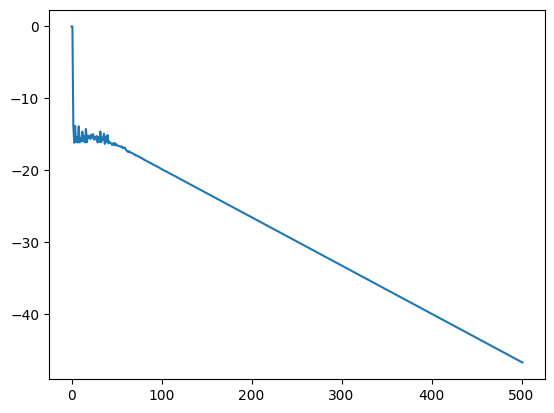

In [39]:
plt.plot(values.keys(), values.values())

In [35]:
import pandas as pd
df = pd.DataFrame([(state, board[*point], point) for state, point in policy.items()], columns=['state', 'target', 'point']).set_index('state')
df.head(50)

,target,point
state,,
0,0.0,"[1, 65]"
1,0.0,"[1, 65]"
2,0.0,"[109, 79]"
3,1.0,"[98, 75]"
4,4.0,"[26, 91]"
5,1.0,"[97, 75]"
6,6.0,"[16, 64]"
7,5.0,"[98, 53]"
8,8.0,"[91, 102]"


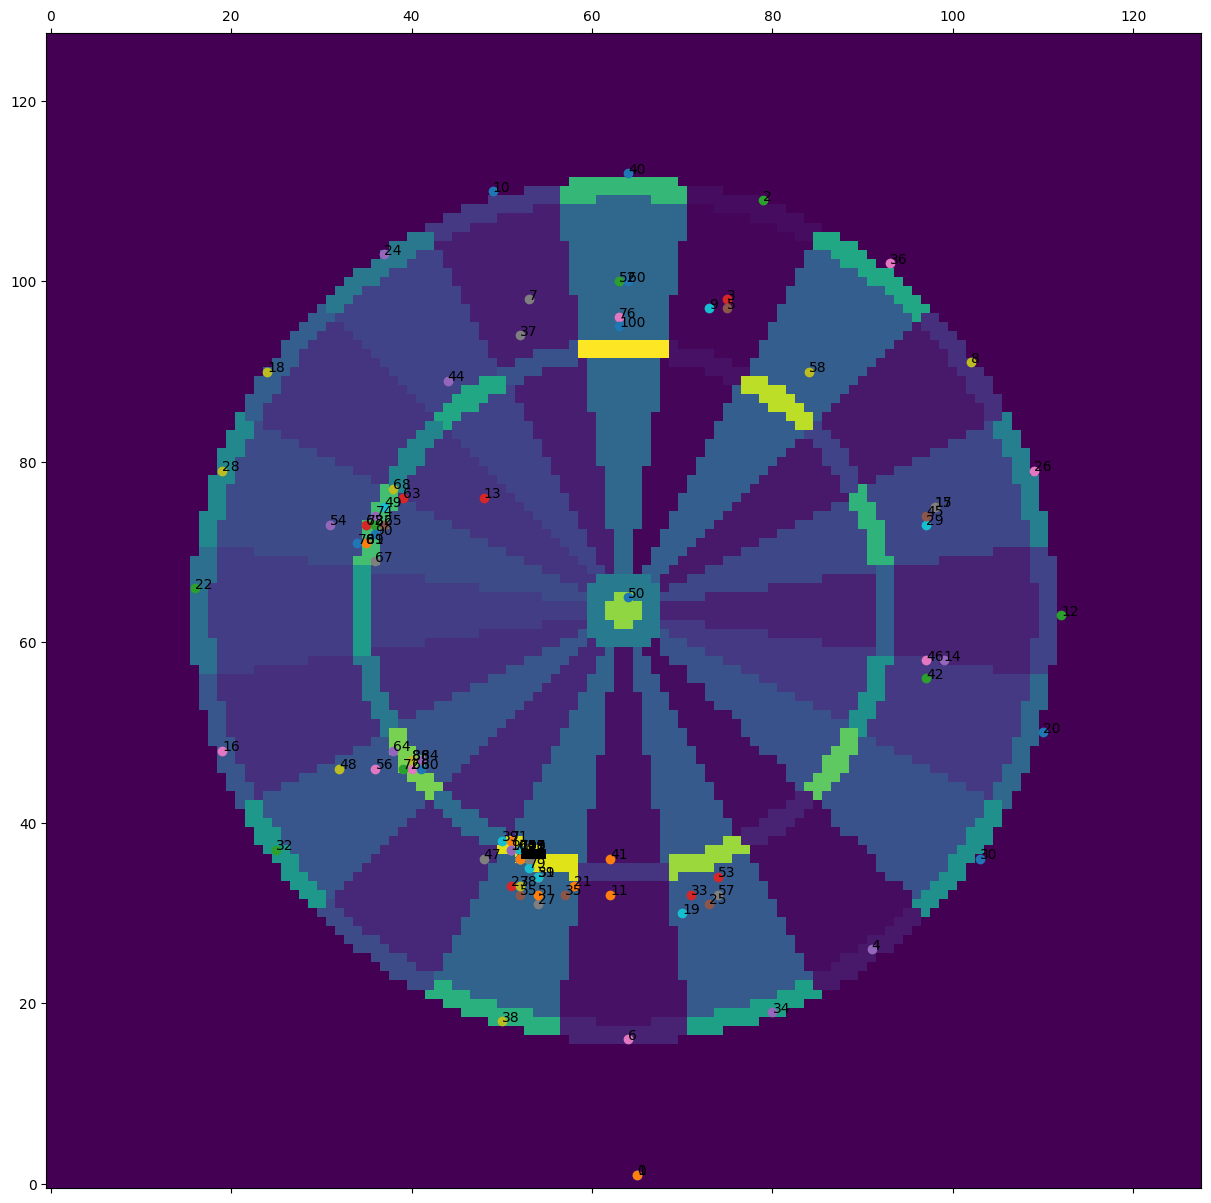

In [36]:
fig, ax = plt.subplots(figsize=(15, 15))
for s, point in policy.items():
    ax.scatter(*point[::-1])
    ax.annotate(s, [point[1], point[0]])
ax.matshow(board, origin='lower')

In [235]:
import pandas as pd
import os

In [236]:
#os.mkdir(f'inf-round_1-player/{board_size}pixel_{sigma}sigma')

In [237]:
#pd.DataFrame(points).to_csv(f'inf-round_1-player/{board_size}pixel_{sigma}sigma/points.csv')

In [238]:
#pd.DataFrame(dict(policy)).T.to_csv(f'inf-round_1-player/{board_size}pixel_{sigma}sigma/policy.csv')

In [239]:
#pd.DataFrame(values.items(), columns=['state', 'value']).set_index('state').to_csv(f'inf-round_1-player/{board_size}pixel_{sigma}sigma/values.csv')